# Exercise 4.A Introduction to Linear Regressin

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [4]:
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


## Working through the sample script

In [7]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [8]:
y_pred = model.predict(X_test)

print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [9]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


The R² score represents how much of the variation in the target variable is explained by the model.A value closer to 1 means the model explains most of the variation well, and a value closer to 0 means the model does not fit the data well

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


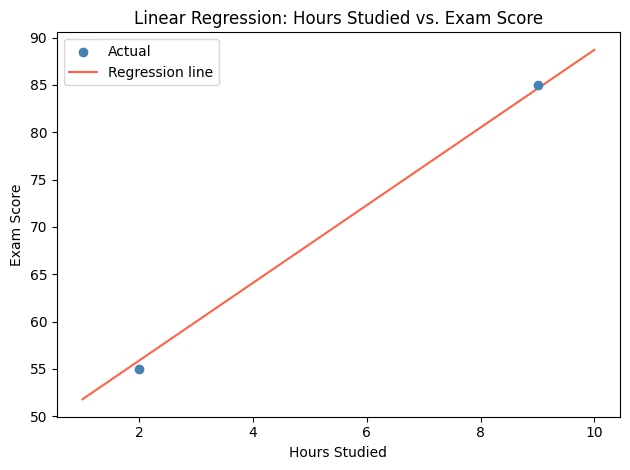

In [10]:
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)

x_range = np.linspace(
    X['hours_studied'].min(),
    X['hours_studied'].max(),
    100
).reshape(-1, 1)

y_line = model.predict(x_range)

plt.plot(x_range, y_line, color='tomato', label='Regression line')

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

The actual data points should cluster around the regression line. If the model fits well the points would be close to the line. If the points are widely scattered, the relationship is weaker and the model is less accurate.

## Lab 2
### Building your own model

In [11]:
ad_data = {
    'monthly_ad_spend': [
        500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
        5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000
    ],
    'monthly_revenue': [
        4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
        12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400,
        20200, 21500, 22100, 23800
    ]
}

df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [12]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print(X2.shape)
print(y2.shape)

(20, 1)
(20,)


In [13]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [14]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

print("Model trained successfully")

Model trained successfully.


In [ ]:
print(model2.coef_[0])
print(model2.intercept_)
# Interpretation: For each additional $1 spent on ads, predicted revenue increases by model2.coef_[0].

## Making predictions and evaluatinf the model

In [15]:
y2_pred = model2.predict(X2_test)

print("Actual values:", list(y2_test))
print("Predicted values:", list(np.round(y2_pred, 2)))

Actual values: [4200, 21500, 19400, 5100]
Predicted values: [np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


In [16]:
r2 = model2.score(X2_test, y2_test)
print(f"R² score: {r2:.3f}")

R² score: 0.998


## Visualizing the results

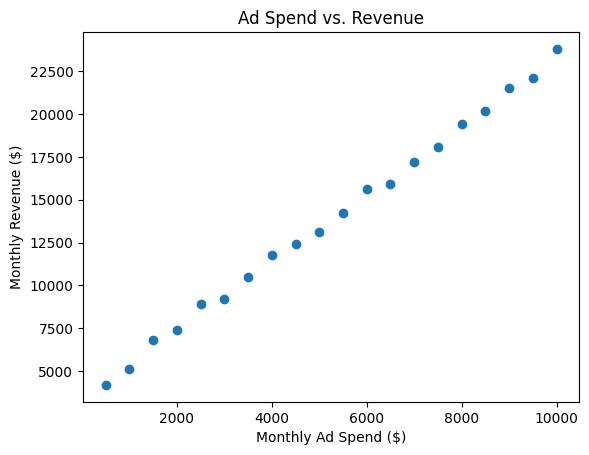

In [17]:
plt.scatter(X2, y2)
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


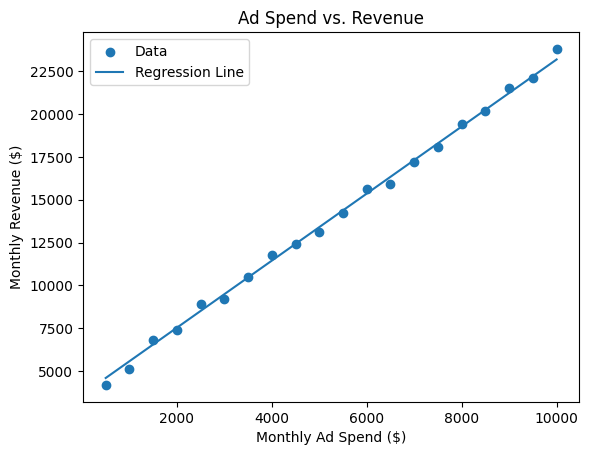

In [18]:
plt.scatter(X2, y2, label='Data')

x_line = np.linspace(X2.min(), X2.max(), 100).reshape(-1, 1)
y_line = model2.predict(x_line)

plt.plot(x_line, y_line, label='Regression Line')

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.show()

The regression line should follow the upward trend of the data points. If the line passes through most points then the model fits well.
If there are a lot points far from the line, the fit is weaker, which should match the R² score